# Steel Surface Defect Benchmarking — NEU-CLS Dataset

Benchmark Qwen2.5-VL-3B and GPT-4.1 on 6-class steel defect classification.
Same methodology as granulometry: zero-shot, few-shot, frontier comparison.

In [1]:
import os

DATASET_DIR = '../../datasets/neu-cls/NEU-DET'

if os.path.exists(DATASET_DIR) and os.path.isdir(os.path.join(DATASET_DIR, 'validation', 'images')):
    n_classes = len(os.listdir(os.path.join(DATASET_DIR, 'validation', 'images')))
    print(f'Dataset exists at {DATASET_DIR} ({n_classes} class folders in validation/images/)')
else:
    print('Dataset not found. Downloading from Kaggle...')
    # Install kaggle CLI if needed
    os.system('pip install kaggle -q')
    
    # Download (requires ~/.kaggle/kaggle.json with your API key)
    # Get your key from: https://www.kaggle.com/settings → API → Create New Token
    dl_dir = '../../datasets/neu-cls'
    os.makedirs(dl_dir, exist_ok=True)
    os.system(f'kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database -p {dl_dir} --unzip')
    
    # Check what was downloaded
    if os.path.exists(DATASET_DIR):
        print(f'Downloaded to {DATASET_DIR}:')
        for item in sorted(os.listdir(DATASET_DIR)):
            print(f'  {item}')
    else:
        print('Download failed. Manual steps:')
        print('1. Go to https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database')
        print('2. Download and extract to ../../datasets/neu-cls/')
        print('3. Expected structure: NEU-DET/train/images/{class}/ and NEU-DET/validation/images/{class}/')


Dataset exists at ../../datasets/neu-cls/NEU-DET (6 class folders in validation/images/)


## Setup

In [2]:
import os, json, re, time, torch, gc, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

print(f'Dataset root: {DATASET_ROOT}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Reference image: {REF_IMAGE_PATH} (exists: {os.path.exists(REF_IMAGE_PATH)})')
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')


Dataset root: ../../datasets/neu-cls/NEU-DET
Test images dir: ../../datasets/neu-cls/NEU-DET/validation/images
Reference image: Sample-images-in-the-NEU-CLS-dataset.png (exists: True)
GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Load Dataset

In [3]:
# Load test manifest or build from directory structure
# We use the validation split (60 per class = 360 total) as our test set
if os.path.exists(TEST_MANIFEST):
    with open(TEST_MANIFEST) as f:
        manifest = json.load(f)
else:
    # Build manifest from validation/images/{class}/ structure
    manifest = []
    for cls_name in CLASSES:
        cls_dir = os.path.join(TEST_IMAGES_DIR, cls_name)
        if not os.path.isdir(cls_dir):
            print(f'WARNING: class dir not found: {cls_dir}')
            continue
        images = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.png','.bmp'))])
        for img in images:
            manifest.append({'image': os.path.join(cls_dir, img), 'class': cls_name})
    print(f'Built manifest from {TEST_IMAGES_DIR}: {len(manifest)} images')
    # Save for reuse
    with open(TEST_MANIFEST, 'w') as f:
        json.dump(manifest, f, indent=2)
    print(f'Saved to {TEST_MANIFEST}')

print(f'Total test images: {len(manifest)}')
cls_counts = Counter(e['class'] for e in manifest)
for cls in sorted(cls_counts):
    print(f'  {cls}: {cls_counts[cls]}')


Total test images: 360
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60


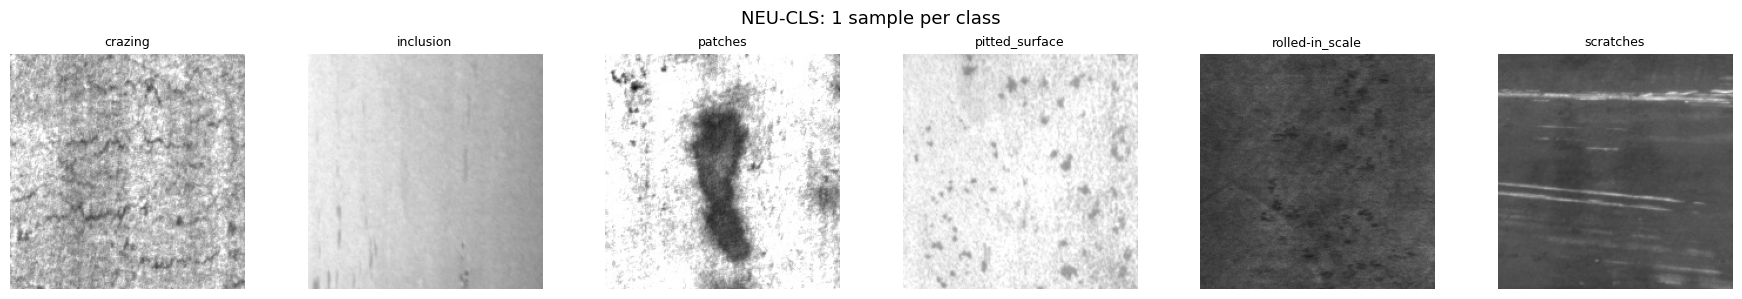

In [4]:
# Preview: show 1 image per class
fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 3))
for i, cls in enumerate(CLASSES):
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry:
        img = Image.open(entry['image']).convert('RGB')
        axes[i].imshow(img, cmap='gray'); axes[i].set_title(cls, fontsize=9); axes[i].axis('off')
        img.close()
plt.suptitle('NEU-CLS: 1 sample per class', fontsize=13)
plt.tight_layout(); plt.show()


Reference image loaded: (850, 622)


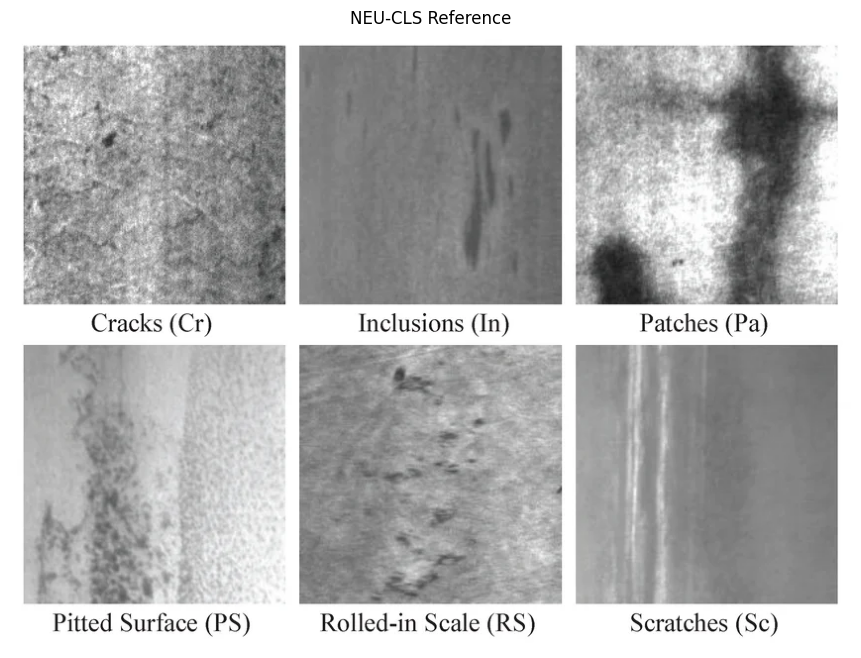

In [5]:
# Load reference image for few-shot
ref_image = None
if os.path.exists(REF_IMAGE_PATH):
    ref_image = Image.open(REF_IMAGE_PATH).convert('RGB')
    print(f'Reference image loaded: {ref_image.size}')
    plt.figure(figsize=(12, 8))
    plt.imshow(ref_image); plt.title('NEU-CLS Reference'); plt.axis('off'); plt.show()
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found')


## Load Model

In [6]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, dtype=torch.bfloat16, device_map='auto',
    max_memory={0: '6GiB', 1: '15GiB'})
print('Model loaded.')


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-20 23:34:51.947378: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 23:34:51.947430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 23:34:51.948938: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 23:34:51.957072: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-04-20 23:34:53.025812: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.21it/s]


Model loaded.


## Helpers

In [7]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w-]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    # Try matching class names directly
    raw_lower = raw.lower()
    for cls in CLASSES:
        if cls in raw_lower: return {'defect_class': cls}
    return None

def infer(img_path, mode='zero-shot', ref_img=None):
    image = Image.open(img_path).convert('RGB')
    if mode == 'few-shot' and ref_img is not None:
        msgs = [{'role':'user','content':[
            {'type':'image','image':ref_img},
            {'type':'text','text':make_prompt_fs_ref()},
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_fs_query()},
        ]}]
        images = [ref_img, image]
    else:
        msgs = [{'role':'user','content':[
            {'type':'image','image':image},
            {'type':'text','text':make_prompt_zs()},
        ]}]
        images = [image]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=images, return_tensors='pt', padding=True).to(model.device)
    t = time.time()
    with torch.no_grad():
        ids = model.generate(**inputs, max_new_tokens=64, temperature=0.7, do_sample=True)
    elapsed = time.time() - t
    out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
    del inputs, ids; image.close(); torch.cuda.empty_cache()
    return out, elapsed

def run_benchmark(manifest, mode, ref_img=None, limit=None):
    data = manifest[:limit] if limit else manifest
    results=[]; correct=0; valid=0; tt=0
    for i, entry in enumerate(data):
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ref_img)
        tt += elapsed
        parsed = parse_response(raw)
        gt = entry['class']
        ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'predicted': parsed,
            'raw': raw, 'correct': ok, 'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        if (i+1) % 20 == 0:
            n = i+1
            print(f'  [{n}/{len(data)}] Acc: {correct}/{n} ({correct/n*100:.0f}%) | JSON: {valid}/{n}')
    return results, correct, valid, tt

print('Helpers ready.')


Helpers ready.


## Quick Test (1 per class, both modes)

In [8]:
quick = []
for cls in CLASSES:
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry: quick.append(entry)

for mode in ['zero-shot', 'few-shot']:
    print(f'\n{"="*50}')
    print(f'Quick test — {mode}')
    print(f'{"="*50}')
    ri = ref_image if mode == 'few-shot' else None
    for entry in quick:
        raw, elapsed = infer(entry['image'], mode=mode, ref_img=ri)
        parsed = parse_response(raw)
        gt = entry['class']
        pred = parsed.get('defect_class', '?') if parsed else '?'
        ok = '✓' if pred == gt else '✗'
        print(f'  {gt:>18} → {pred:<18} {ok} ({elapsed:.1f}s)')



Quick test — zero-shot
             crazing → inclusion          ✗ (3.0s)
           inclusion → patches            ✗ (2.1s)
             patches → scratches          ✗ (2.1s)
      pitted_surface → inclusion          ✗ (1.8s)
     rolled-in_scale → patch              ✗ (2.3s)
           scratches → inclusion          ✗ (1.9s)

Quick test — few-shot
             crazing → inclusion          ✗ (2.8s)
           inclusion → scratches          ✗ (3.0s)
             patches → inclusion          ✗ (2.8s)
      pitted_surface → inclusion          ✗ (3.1s)
     rolled-in_scale → scratches          ✗ (2.9s)
           scratches → scratches          ✓ (2.8s)


## Full Benchmark — Zero-Shot

In [9]:
print('Running zero-shot...')
zs_results, zs_correct, zs_valid, zs_time = run_benchmark(manifest, 'zero-shot')
n = len(zs_results)
print(f'\nZero-shot: Acc={zs_correct}/{n} ({zs_correct/n*100:.1f}%) | JSON={zs_valid}/{n} | Time={zs_time/n:.1f}s/img')


Running zero-shot...
  [20/360] Acc: 2/20 (10%) | JSON: 20/20
  [40/360] Acc: 5/40 (12%) | JSON: 40/40
  [60/360] Acc: 11/60 (18%) | JSON: 60/60
  [80/360] Acc: 17/80 (21%) | JSON: 80/80
  [100/360] Acc: 26/100 (26%) | JSON: 100/100
  [120/360] Acc: 32/120 (27%) | JSON: 120/120
  [140/360] Acc: 39/140 (28%) | JSON: 140/140
  [160/360] Acc: 43/160 (27%) | JSON: 160/160
  [180/360] Acc: 45/180 (25%) | JSON: 180/180
  [200/360] Acc: 46/200 (23%) | JSON: 200/200
  [220/360] Acc: 47/220 (21%) | JSON: 220/220
  [240/360] Acc: 47/240 (20%) | JSON: 240/240
  [260/360] Acc: 47/260 (18%) | JSON: 260/260
  [280/360] Acc: 48/280 (17%) | JSON: 280/280
  [300/360] Acc: 48/300 (16%) | JSON: 300/300
  [320/360] Acc: 56/320 (18%) | JSON: 320/320
  [340/360] Acc: 66/340 (19%) | JSON: 340/340
  [360/360] Acc: 78/360 (22%) | JSON: 360/360

Zero-shot: Acc=78/360 (21.7%) | JSON=360/360 | Time=1.9s/img


## Full Benchmark — Few-Shot

In [10]:
print('Running few-shot...')
fs_results, fs_correct, fs_valid, fs_time = run_benchmark(manifest, 'few-shot', ref_img=ref_image)
n = len(fs_results)
print(f'\nFew-shot: Acc={fs_correct}/{n} ({fs_correct/n*100:.1f}%) | JSON={fs_valid}/{n} | Time={fs_time/n:.1f}s/img')


Running few-shot...
  [20/360] Acc: 1/20 (5%) | JSON: 20/20
  [40/360] Acc: 5/40 (12%) | JSON: 40/40
  [60/360] Acc: 8/60 (13%) | JSON: 60/60
  [80/360] Acc: 12/80 (15%) | JSON: 80/80
  [100/360] Acc: 18/100 (18%) | JSON: 100/100
  [120/360] Acc: 22/120 (18%) | JSON: 120/120
  [140/360] Acc: 24/140 (17%) | JSON: 140/140
  [160/360] Acc: 25/160 (16%) | JSON: 160/160
  [180/360] Acc: 26/180 (14%) | JSON: 180/180
  [200/360] Acc: 26/200 (13%) | JSON: 200/200
  [220/360] Acc: 27/220 (12%) | JSON: 220/220
  [240/360] Acc: 27/240 (11%) | JSON: 240/240
  [260/360] Acc: 27/260 (10%) | JSON: 260/260
  [280/360] Acc: 27/280 (10%) | JSON: 280/280
  [300/360] Acc: 27/300 (9%) | JSON: 300/300
  [320/360] Acc: 44/320 (14%) | JSON: 320/320
  [340/360] Acc: 63/340 (19%) | JSON: 340/340
  [360/360] Acc: 82/360 (23%) | JSON: 360/360

Few-shot: Acc=82/360 (22.8%) | JSON=360/360 | Time=2.9s/img


## Results

In [11]:
n = len(zs_results)
print(f'{"Method":<20} {"Accuracy":>10} {"JSON Valid":>12} {"Time/img":>10}')
print('=' * 54)
print(f'{"Qwen ZS":<20} {zs_correct/n*100:>9.1f}% {zs_valid/n*100:>11.0f}% {zs_time/n:>9.1f}s')
print(f'{"Qwen FS":<20} {fs_correct/n*100:>9.1f}% {fs_valid/n*100:>11.0f}% {fs_time/n:>9.1f}s')
print(f'{"Random chance":<20} {100/6:>9.1f}%')

# Per-class
print(f'\nPer-class accuracy (zero-shot):')
for cls in CLASSES:
    cr = [r for r in zs_results if r['class'] == cls]
    correct = sum(1 for r in cr if r['correct'])
    print(f'  {cls:>18}: {correct}/{len(cr)}')


Method                 Accuracy   JSON Valid   Time/img
Qwen ZS                   21.7%         100%       1.9s
Qwen FS                   22.8%         100%       2.9s
Random chance             16.7%

Per-class accuracy (zero-shot):
             crazing: 11/60
           inclusion: 21/60
             patches: 13/60
      pitted_surface: 2/60
     rolled-in_scale: 1/60
           scratches: 30/60


## Save Results

In [12]:
for label, results, correct, valid, tt in [
    ('zero-shot', zs_results, zs_correct, zs_valid, zs_time),
    ('few-shot', fs_results, fs_correct, fs_valid, fs_time),
]:
    n = len(results)
    with open(f'benchmark_results_{label}.json', 'w') as f:
        json.dump({'model': MODEL_ID, 'mode': label, 'dataset': 'NEU-CLS',
            'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
            'json_validity_pct': round(valid/n*100, 1),
            'avg_inference_time_s': round(tt/n, 2),
            'results': results}, f, indent=2)
    print(f'Saved benchmark_results_{label}.json')


Saved benchmark_results_zero-shot.json
Saved benchmark_results_few-shot.json
